<a href="https://colab.research.google.com/github/Ankwoji/Projects/blob/Ava/Alzheimer's_Recognition_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import lightgbm as lgbtq
import pickle
from sklearn.metrics import accuracy_score
from PIL import Image
import numpy as np
import io
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
train_data = pd.read_parquet('/content/drive/MyDrive/train-00000-of-00001-c08a401c53fe5312.parquet')
test_data = pd.read_parquet('/content/drive/MyDrive/test-00000-of-00001-44110b9df98c5585.parquet')

In [ ]:
def preprocess_image(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert('L')  # Convert to grayscale if necessary
    image = image.resize((128, 128))  # Resize image
    return np.array(image).flatten()  # Flatten to create a 1D array

2


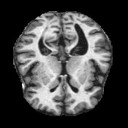

In [ ]:
X_train = np.array([preprocess_image(img_bytes['bytes']) for img_bytes in train_data['image']])
y_train = train_data['label'].values

valz = 8
image = Image.open(io.BytesIO(((test_data['image'][valz])['bytes'])))
val = test_data['label'][valz]

X_test = np.array([preprocess_image(img_bytes['bytes']) for img_bytes in test_data['image']])
y_test = test_data['label'].values

train_dataset = lgbtq.Dataset(X_train, label=y_train)
test_dataset = lgbtq.Dataset(X_test, label=y_test, reference=train_dataset)



print(val)
image

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)

y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
history = cnn_model.fit(X_train, y_train_cat, epochs=1, batch_size=32, validation_data=(X_test, y_test_cat))

# Extract features using the trained CNN model (remove the last dense layer)
feature_extractor = Sequential(cnn_model.layers[:-1])

# Get the features for LightGBM
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

# Prepare the LightGBM datasets
train_dataset = lgbtq.Dataset(X_train_features, label=y_train)
test_dataset = lgbtq.Dataset(X_test_features, label=y_test, reference=train_dataset)

NameError: name 'history' is not defined

In [ ]:
params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'learning_rate': 0.3,
    'num_leaves': 70,
    'max_depth': -1,
    'min_data_in_leaf': 31,
    'lambda_l1': 0.08,
    'lambda_l2': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1
}

In [ ]:
model = lgbtq.train(params, train_dataset, num_boost_round=10)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9414
[LightGBM] [Info] Number of data points in the train set: 5120, number of used features: 37
[LightGBM] [Info] Start training from score -1.956118
[LightGBM] [Info] Start training from score -4.649089
[LightGBM] [Info] Start training from score -0.690806
[LightGBM] [Info] Start training from score -1.055979
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [ ]:
# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)

# accuracy = accuracy_score(y_test, y_pred_classes)

# print(accuracy)

# Reshape X_test to match the shape expected by the LightGBM model # Now predict using the reshaped data
X_test_features_reshaped = X_test_features.reshape(X_test_features.shape[0], -1)


y_pred = model.predict(X_test_features_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)

print(accuracy)



0.73125


In [ ]:
model.save_model('/content/drive/MyDrive/alzheimer_disease_model.txt')

In [ ]:
file = 'trained_model.pkl'
pickle.dump(model, open(file, 'wb'))
print('Trained LGB model was saved!')

Trained LGB model was saved!
